# TESSERA embeddings on the EuroCrops pilot chips, explained

The third notebook in the series, after `eurocrops_terramind_pilot.ipynb` and `eurocrops_prithvi_pilot.ipynb`. Same chips, labels, parcel draws, training script and evaluation. What changes is fundamental: **there is no encoder to run.** TESSERA (Feng et al., 2025) ships **precomputed embeddings**, one 128-dimensional vector per 10 m pixel per year. We download them onto our chip grid and train only a small head.

| | TerraMind / Prithvi | TESSERA v1 |
|---|---|---|
| what we download | model weights | the embeddings themselves |
| encoder input | our 12 monthly Sentinel-2 composites | each pixel's whole-year **Sentinel-1 and Sentinel-2** time series, processed by the TESSERA team |
| spatial context in the encoder | yes, ViT attention over 16 x 16 patches | **none**: every pixel is encoded on its own |
| decoder input | 14 x 14 token grid, 160 m | **224 x 224 raster, 10 m** |
| time axis we can see | 12 months | none; the year is folded into the 128 numbers |
| head in this notebook | neck + UNet decoder, 53 to 149 M parameters | **per-pixel MLP, 0.2 M parameters** |

In CLAUDE.md's terms, TESSERA sits in the **`pixel_raster` resolution group** with AlphaEarth. Its numbers are compared head-to-head within that group. A comparison against the token-grid models is descriptive, because input resolution, input data and head all differ at once (section 7).

**Before running.** Select the kernel **Python 3.11 (gfm4agri)**. The embeddings must have been exported with `scripts/data/build_tessera_chips.py`, which takes about 7 minutes for the 12 pilot chips. If no checkpoint exists, section 5 trains one, in about 3 minutes. Every score is on the 4 validation chips of a pipeline test set, not a thesis result.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
import yaml

REPO = Path.cwd().resolve()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

from gfm4agri.benchmark.backbones import get_backbone
from gfm4agri.benchmark.segmentation import build_task, count_params
from gfm4agri.benchmark.segmentation_data import EuroCropsSegDataModule

CONFIG = REPO / "configs/seg/tessera_v1_mlp_ee_pilot.yaml"
cfg = yaml.safe_load(CONFIG.read_text())
ROOT = REPO / cfg["data"]["root"]
RUN_DIR = REPO / cfg["output_root"] / cfg["run_name"] / f"P100_draw0_seed{cfg['seed']}"
CKPT = RUN_DIR / "checkpoints" / "best-loss.ckpt"
OTHERS = {"TerraMind v1 large": REPO / "results/seg/terramind_v1_large_ee_pilot",
          "Prithvi-EO-2.0 600M TL": REPO / "results/seg/prithvi_eo_v2_600_tl_ee_pilot"}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(yaml.safe_dump(cfg, sort_keys=False))
print("embeddings exported:", (ROOT / "tessera_v1.json").exists(), "| checkpoint present:", CKPT.exists())

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run_name: tessera_v1_mlp_ee_pilot
seed: 0
data:
  root: data/eurocrops_chips/EE_2021_pilot
  normalisation: chips
  batch_size: 4
  num_workers: 4
  augment: true
label_budget:
  mode: dense
  K: 5
  draw_seed: 0
model:
  backbone: tessera_v1
  lr: 0.001
  weight_decay: 0.05
  head_dropout: 0.2
  loss: ce
trainer:
  max_epochs: 40
  precision: 16-mixed
  log_every_n_steps: 1
output_root: results/seg

embeddings exported: True | checkpoint present: True


## 1. How the embeddings get onto our chips

TESSERA's embeddings are served from Source Cooperative as a **Zarr v3 store** (`data.source.coop/tessera/tessera/zarr/v1`):
- one group per UTM zone (Estonia is zone 35, EPSG:32635), on the 10 m grid the embeddings were produced on;
- years 2017 to 2025 along a time axis;
- 128 dimensions stored as **int8, with one float32 scale per pixel**, so a pixel's vector is `int8 values x scale`;
- sharded into **32 x 32 pixel pieces**, so a chip can be read without downloading whole tiles.

`scripts/data/build_tessera_chips.py` (built on `src/gfm4agri/embeddings/tessera.py`), for each chip:
1. projects the chip's EPSG:3035 footprint into UTM zone 35 and reads that window, plus an 8-pixel margin, for 2021;
2. dequantises it (int8 x scale; pixels with no data become NaN);
3. warps it onto the chip's exact EPSG:3035 grid by **nearest neighbour**, so every output pixel holds a genuine TESSERA vector rather than an average of two;
4. writes `<chip>_tessera.tif` next to the chip's S2 image, mask and parcel raster.

Two things did not work as documented. The `geotessera` Python client that knows the new server needs Python 3.12, and ours is 3.11, so the store is read directly with `zarr`. The per-dimension statistics stored in the Zarr are numerically broken (means around 1e29), so normalisation uses statistics computed on our training chips.

The provenance lands in `tessera_v1.json`. `manifest.json` stays untouched, because the TerraMind and Prithvi results are stamped with its hash.

In [2]:
side = json.loads((ROOT / "tessera_v1.json").read_text())
print(json.dumps(side["source"], indent=1))
print("resampling:", side["resampling"])
pd.DataFrame(side["chips"])[["chip_id", "split", "seconds", "nodata_share", "zone_crs"]]

{
 "store": "https://data.source.coop/tessera/tessera/zarr/v1",
 "model_version": "1.0",
 "model": "https://geotessera.org/model/1.0",
 "year": 2021,
 "product": "annual embedding: one 128-d vector per 10 m pixel from the calendar-year Sentinel-1 and Sentinel-2 time series"
}
resampling: nearest neighbour from the store's native UTM grid; int8 x per-pixel scale dequantised before warping; no-coverage pixels are NaN


,chip_id,split,seconds,nodata_share,zone_crs
0,EE_02299_01803,train,83.8,0.0,EPSG:32635
1,EE_02304_01818,train,95.7,0.0,EPSG:32635
2,EE_02329_01782,train,78.9,0.0,EPSG:32635
3,EE_02338_01809,val,93.7,0.0,EPSG:32635
4,EE_02340_01843,train,53.1,0.0,EPSG:32635
5,EE_02346_01825,train,162.8,0.0,EPSG:32635
6,EE_02354_01821,train,224.1,0.0,EPSG:32635
7,EE_02363_01794,train,93.0,0.0,EPSG:32635
8,EE_02370_01797,val,225.6,0.0,EPSG:32635
9,EE_02373_01780,val,164.4,0.0,EPSG:32635


## 2. What the embedding looks like

A 128-dimensional vector cannot be plotted directly, so the first three principal components are shown as red, green and blue, next to the July Sentinel-2 image and with the EuroCrops parcel outlines drawn on top.

What to look for: the embedding is **piecewise constant over parcels**. Boundaries in the PCA image fall on the declared parcel edges, and each field is nearly one colour. TESSERA has no spatial context, so this is not smoothing. Pixels of one field share a year-long history, so they receive near-identical vectors. That also confirms the reprojection is aligned with our labels.

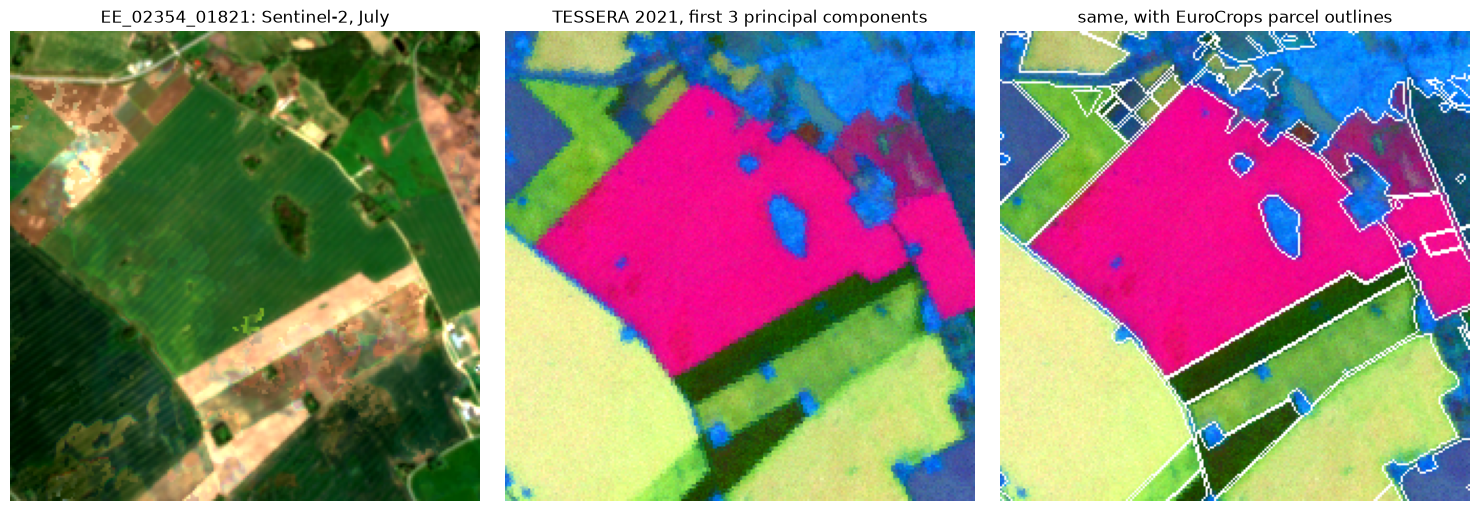

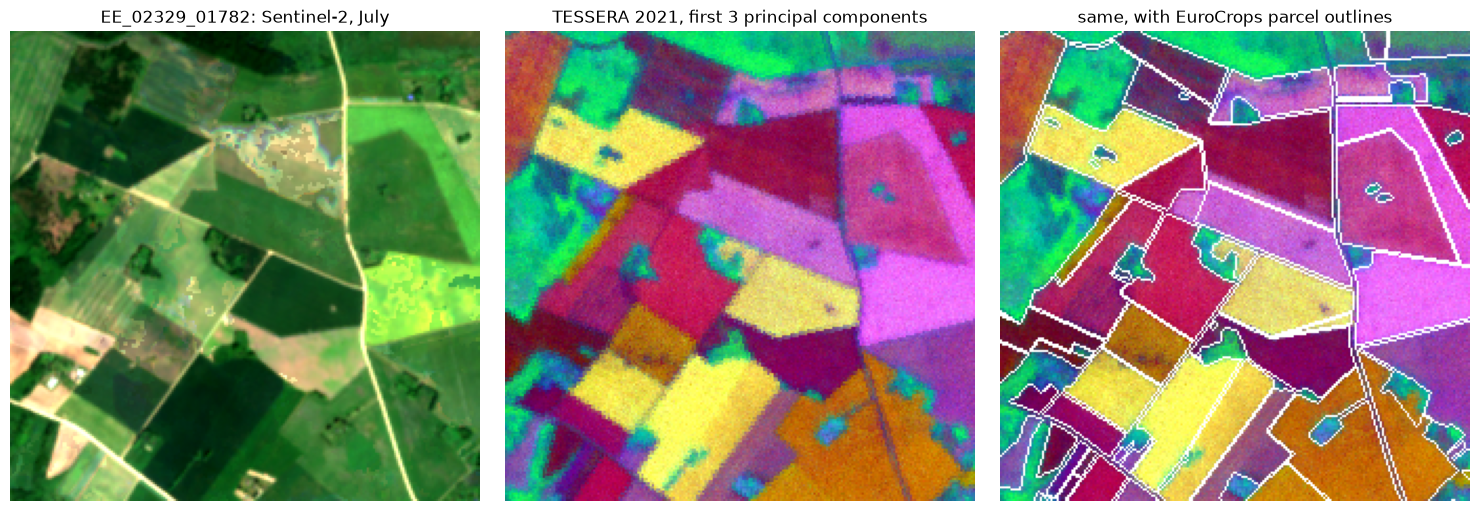

In [3]:
from sklearn.decomposition import PCA
from skimage.segmentation import find_boundaries

def load(split, cid, suffix):
    with rasterio.open(ROOT / f"{split}_chips" / f"{cid}{suffix}") as src:
        return src.read()

def pca_rgb(emb, pca=None):
    X = emb.reshape(emb.shape[0], -1).T
    pca = pca or PCA(3, random_state=0).fit(X)
    p = pca.transform(X); lo, hi = np.percentile(p, [2, 98], 0)
    return np.clip((p - lo) / (hi - lo), 0, 1).reshape(*emb.shape[1:], 3), pca

def s2_rgb(cid, split, month=6):
    a = load(split, cid, "_merged.tif").reshape(12, 12, 224, 224)[month][[3, 2, 1]].transpose(1, 2, 0).astype(float)
    lo, hi = np.percentile(a, [2, 98]); return np.clip((a - lo) / (hi - lo), 0, 1)

manifest = json.loads((ROOT / "manifest.json").read_text())
train_ids = [c["chip_id"] for c in manifest["chips"] if c["split"] == "train"]
for cid in train_ids[:2]:
    emb = load("training", cid, "_tessera.tif"); ids = load("training", cid, ".parcels.tif")[0]
    rgb, _ = pca_rgb(emb); edge = rgb.copy(); edge[find_boundaries(ids, mode="inner")] = 1
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(s2_rgb(cid, "training")); ax[0].set_title(f"{cid}: Sentinel-2, July")
    ax[1].imshow(rgb); ax[1].set_title("TESSERA 2021, first 3 principal components")
    ax[2].imshow(edge); ax[2].set_title("same, with EuroCrops parcel outlines")
    [a.axis("off") for a in ax]; plt.tight_layout()

**Is the class signal in there?** Average the embedding over each training parcel and project the parcel means to 2-D. If crops form clusters here, a simple head should separate them. This is also the bridge to the per-parcel view of the original proposal: a parcel's mean TESSERA vector is exactly an `emb_zonal` feature.

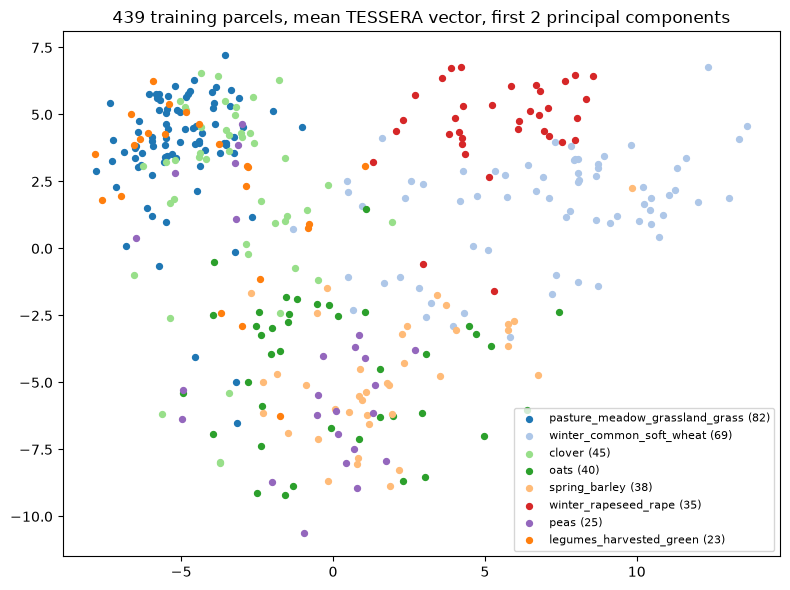

In [4]:
rows = []
for cid in train_ids:
    emb = load("training", cid, "_tessera.tif").reshape(128, -1)
    ids = load("training", cid, ".parcels.tif")[0].ravel(); msk = load("training", cid, ".mask.tif")[0].ravel()
    for pid in np.unique(ids[(ids > 0) & (msk >= 0)]):
        sel = ids == pid
        if sel.sum() >= 30:
            rows.append((np.bincount(msk[sel][msk[sel] >= 0]).argmax(), emb[:, sel].mean(1)))
NAMES = [c["name"] for c in manifest["classes"]]
cls = np.array([r[0] for r in rows]); Z = np.stack([r[1] for r in rows])
Z2 = PCA(2, random_state=0).fit_transform((Z - Z.mean(0)) / Z.std(0))
cmap = plt.get_cmap("tab20", len(NAMES))
top = pd.Series(cls).value_counts().index[:8]
fig, ax = plt.subplots(figsize=(8, 6))
for k in top:
    ax.scatter(*Z2[cls == k].T, s=18, color=cmap(k), label=f"{NAMES[k]} ({(cls == k).sum()})")
ax.set_title(f"{len(Z)} training parcels, mean TESSERA vector, first 2 principal components")
ax.legend(fontsize=8); plt.tight_layout()

Even two principal components of the parcel means separate several crops: winter rapeseed and winter wheat occupy distinct regions, and grassland, clover and legumes harvested green cluster together as the mown-grass family. Spring barley, oats and peas overlap. That is expected, because barley, oats and spring wheat share a calendar, and it is where the remaining 126 dimensions and the head have to work.

## 3. From file to tensor

The same `EuroCropsSegDataModule`. The registry entry says `representation: tessera_v1`, so the data module:
- reads `*_tessera.tif` instead of `*_merged.tif`, with 128 bands (`TESSERA_000` to `TESSERA_127`) and **no time axis**; the sample is `(128, 224, 224)`;
- reuses the **same masks, parcel rasters and split files**, so the K-parcel draws are identical to TerraMind's and Prithvi's;
- standardises each dimension with the **training-chip statistics** in `tessera_v1.json`, since an embedding has no pretraining input distribution to match;
- applies the D4 flips and rotations. They are **exact** here: TESSERA encodes every pixel independently, so rotating the chip rotates the embedding raster and nothing else. For the ViTs this is only approximately true.

In [5]:
d = cfg["data"]
dm = EuroCropsSegDataModule(ROOT, cfg["model"]["backbone"], normalisation=d["normalisation"],
                            batch_size=d["batch_size"], num_workers=0, augment=False)
dm.setup("fit")
s = dm.train_dataset[0]
print("representation:", dm.representation, "| bands:", dm.bands[:3], "...", dm.bands[-1])
print("image", tuple(s["image"].shape), "(dims, H, W) | mask", tuple(s["mask"].shape))
x = dm.aug(next(iter(dm.train_dataloader())))["image"]
print("after normalisation, per-dimension mean ranges over", np.round([x.mean((0, 2, 3)).min(), x.mean((0, 2, 3)).max()], 2),
      "and std over", np.round([x.std((0, 2, 3)).min(), x.std((0, 2, 3)).max()], 2))

representation: tessera_v1 | bands: ['TESSERA_000', 'TESSERA_001', 'TESSERA_002'] ... TESSERA_127
image (128, 224, 224) (dims, H, W) | mask (224, 224)


after normalisation, per-dimension mean ranges over [-0.25  0.28] and std over [0.85 1.11]


## 4. The model: an identity backbone and a per-pixel MLP

The registry entry turns TerraTorch's `EncoderDecoderFactory` into a pure head:
- **`IdentityBackbone`** returns the embedding unchanged. The encoder already ran, on the TESSERA team's machines.
- **No necks.** There are no tokens to reshape and no pyramid to build: the input is already a 10 m raster.
- **`PixelMLPDecoder`** (`src/gfm4agri/benchmark/decoders.py`) has two hidden layers of 512 and 256 units, each with ReLU, batch norm and dropout. They are written as 1 x 1 convolutions, so the MLP is applied to every pixel independently. With TerraTorch's 1 x 1 segmentation head it is exactly the three-layer MLP the TESSERA authors use for crop classification.

**Why not the TerraMind/Prithvi head?** Their neck and UNet decoder exist to turn a 14 x 14 token grid into a 224 x 224 map. Here there is nothing to upsample. Reusing them would either downsample TESSERA's 10 m raster to fit, throwing away its main advantage, or put a 50 to 150 M parameter decoder on 128 numbers per pixel, which is absurd with scarce labels.

The MLP also sees **only the pixel itself**, so its score measures the embedding and nothing else. A light spatial UNet is the planned second head for this group. The gap between the two heads will show how much neighbourhood context adds at each K.

In [6]:
spec = get_backbone(cfg["model"]["backbone"])
print("resolution group:", spec.resolution_group, "| representation:", spec.representation)
print(json.dumps({**spec.model_args(dm.bands, 1), **{"decoder": "PixelMLPDecoder", "decoder_hidden": [512, 256]}}, indent=1))
m = cfg["model"]
task = build_task(m["backbone"], num_classes=len(NAMES), class_names=NAMES, bands=dm.bands,
                  n_timesteps=1, ignore_index=manifest["ignore_index"], lr=m["lr"],
                  weight_decay=m["weight_decay"], head_dropout=m["head_dropout"], loss=m["loss"])
print(task.model.decoder)
table = pd.DataFrame({"TESSERA v1 + MLP": count_params(task)})
for name, run in OTHERS.items():
    r = run / "P100_draw0_seed0/results.json"
    if r.exists():
        table[name] = pd.Series(json.loads(r.read_text())["params"])
(table.fillna(0) / 1e6).round(3).rename_axis("parameters, millions").loc[lambda t: t.sum(axis=1) > 0]

resolution group: pixel_raster | representation: tessera_v1
{
 "backbone": "IdentityBackbone",
 "backbone_out_channels": [
  128
 ],
 "necks": [],
 "decoder": "PixelMLPDecoder",
 "decoder_hidden": [
  512,
  256
 ]
}
PixelMLPDecoder(
  (mlp): Sequential(
    (0): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
  )
)


,TESSERA v1 + MLP,TerraMind v1 small,Prithvi-EO-2.0 300M TL
"parameters, millions",,,
encoder_total,0.000,22.465,303.886
decoder_total,0.199,53.788,12.869
decoder_trainable,0.199,53.788,12.869
head_total,0.005,0.001,0.001
head_trainable,0.005,0.001,0.001
trainable_total,0.204,149.352,53.281
all_total,0.204,171.816,357.168


## 5. Training

With no encoder in the loop, a training step is just the MLP over 4 x 224 x 224 pixels. The 40 epochs take about 3 minutes, most of it spent reading 128-band float rasters rather than computing. The learning rate is **1e-3** rather than the 1e-4 used for the token-grid decoders, because this is a small head trained from scratch. The configuration file records the difference.

```bash
poetry run python scripts/seg/train.py -c configs/seg/tessera_v1_mlp_ee_pilot.yaml
poetry run python scripts/seg/train.py -c configs/seg/tessera_v1_mlp_ee_pilot.yaml --set label_budget.mode=pct label_budget.pct=5
```

In [7]:
TRAIN_HERE = not CKPT.exists()
if TRAIN_HERE:
    import lightning.pytorch as pl
    pl.seed_everything(cfg["seed"], workers=True)
    dm_train = EuroCropsSegDataModule(ROOT, m["backbone"], normalisation=d["normalisation"],
                                      batch_size=d["batch_size"], num_workers=d["num_workers"], augment=d["augment"])
    ckpt_cb = pl.callbacks.ModelCheckpoint(dirpath=CKPT.parent, monitor="val/loss", mode="min",
                                           filename="best-loss", save_weights_only=True)
    trainer = pl.Trainer(accelerator="auto", devices=1, precision=cfg["trainer"]["precision"],
                         max_epochs=cfg["trainer"]["max_epochs"], callbacks=[ckpt_cb],
                         logger=pl.loggers.CSVLogger(RUN_DIR, name="logs"), log_every_n_steps=1)
    trainer.fit(task, datamodule=dm_train)
state = torch.load(CKPT, map_location="cpu", weights_only=False)["state_dict"]
print(task.load_state_dict(state))
task = task.to(DEVICE).eval()
r = json.loads((RUN_DIR / "results.json").read_text()) if (RUN_DIR / "results.json").exists() else None
if r: print(f"script run: fit {r['fit_seconds']:.0f} s, peak GPU {r['peak_gpu_gb']} GB")

<All keys matched successfully>


script run: fit 191 s, peak GPU 2.16 GB


## 6. Results

**Learning curves** against the two token-grid models, on the same validation chips. TESSERA's head starts from a far better representation. After one epoch it already matches the token-grid models' *final* macro F1, and it plateaus by about epoch 15. The gap between training and validation loss is large here too: even 0.2 M parameters can memorise 8 chips. Validation loss stays flat rather than rising, though, so early stopping around epoch 15 would lose nothing.

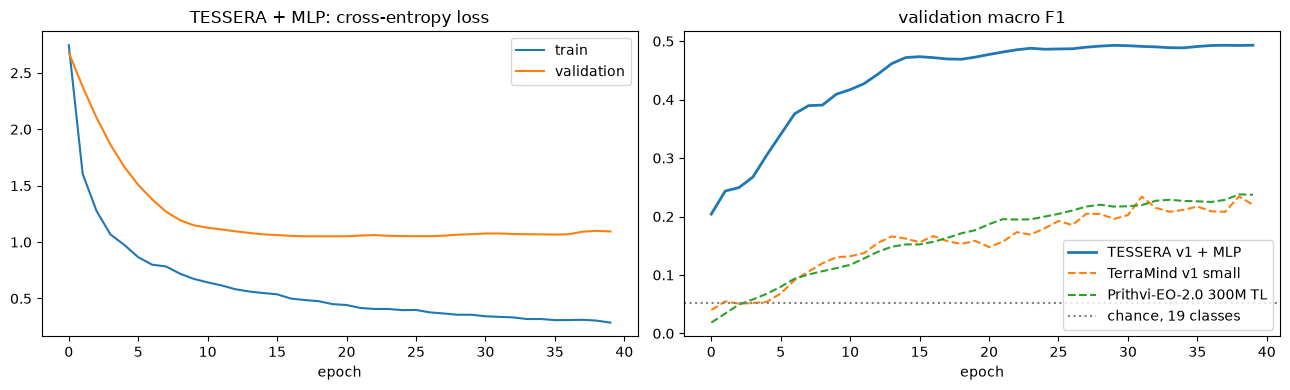

In [8]:
def history(run_dir):
    logs = sorted((run_dir / "logs").glob("version_*/metrics.csv"))
    return pd.read_csv(logs[-1]) if logs else None

h = history(RUN_DIR)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tr = h.dropna(subset=["train/loss"]).groupby("epoch")["train/loss"].mean(); va = h.dropna(subset=["val/loss"]).set_index("epoch")
axes[0].plot(tr.index, tr.values, label="train"); axes[0].plot(va.index, va["val/loss"], label="validation")
axes[0].set_title("TESSERA + MLP: cross-entropy loss"); axes[0].legend()
axes[1].plot(va.index, va["val/F1_Score"], lw=2, label="TESSERA v1 + MLP")
for name, run in OTHERS.items():
    ho = history(run / "P100_draw0_seed0")
    if ho is not None:
        vo = ho.dropna(subset=["val/loss"]).set_index("epoch"); axes[1].plot(vo.index, vo["val/F1_Score"], ls="--", label=name)
axes[1].axhline(1 / 19, ls=":", c="grey", label="chance, 19 classes"); axes[1].set_title("validation macro F1"); axes[1].legend()
for a in axes: a.set_xlabel("epoch")
plt.tight_layout()

**Prediction maps.** Compare them with the TerraMind and Prithvi notebooks: the blocky 160 m blobs are gone, and predictions follow field edges, because every 10 m pixel is classified from its own vector. The characteristic error of a per-pixel head is also visible: **speckle**, isolated pixels inside a field assigned to another class. That speckle is what a spatial head, or a parcel-level majority vote, would clean up.

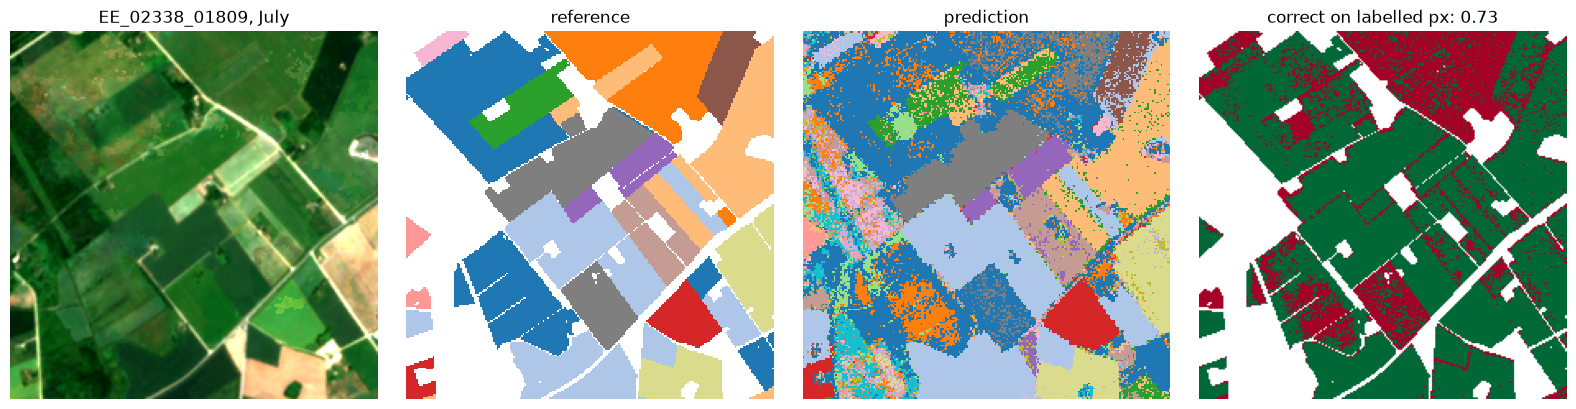

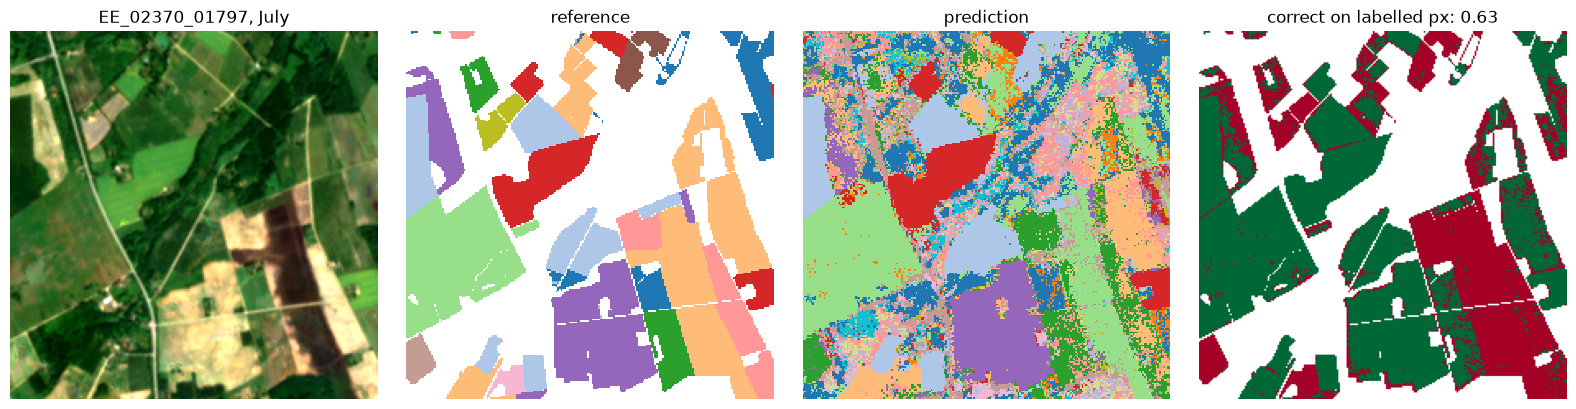

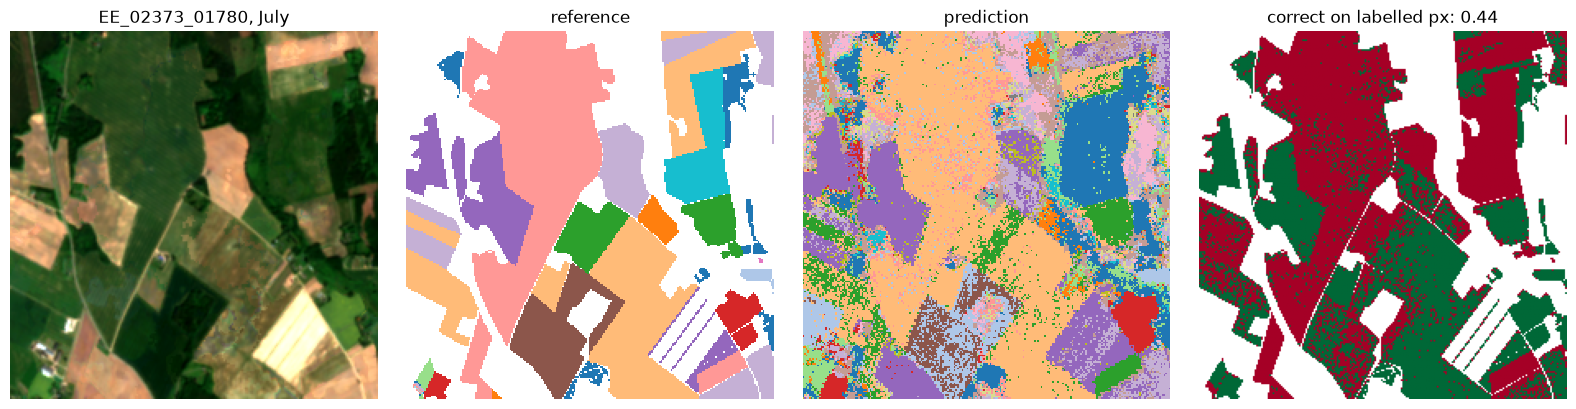

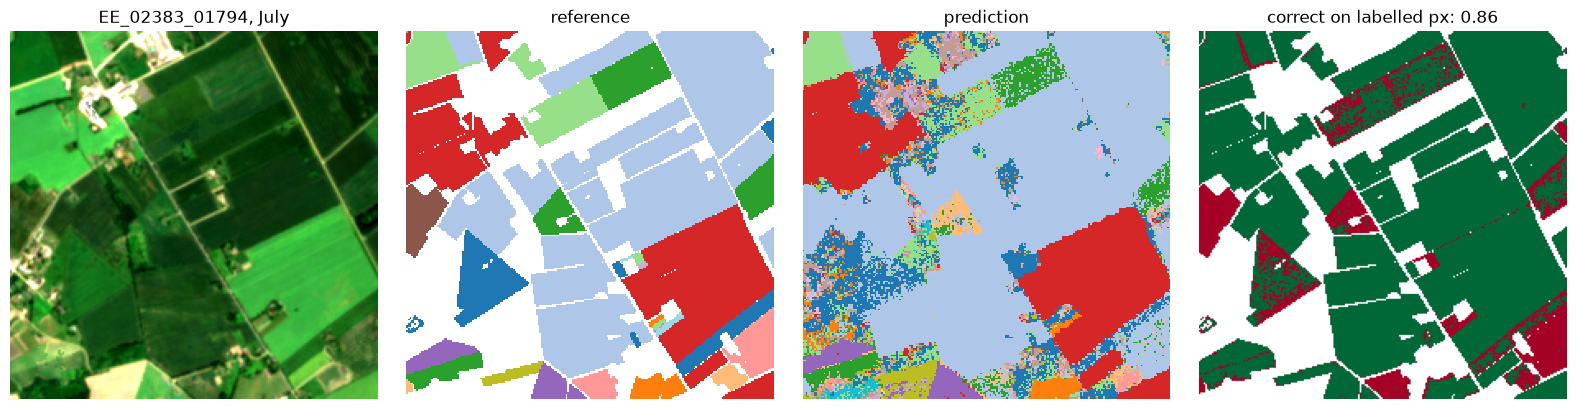

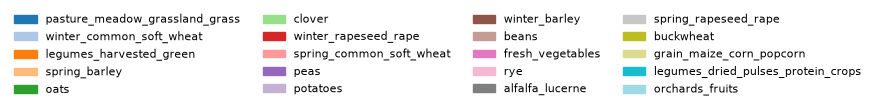

In [9]:
preds, masks, embs = [], [], []
with torch.no_grad():
    for b in dm.val_dataloader():
        xv = dm.aug(b)["image"].to(DEVICE)
        preds.append(task(xv).output.argmax(1).cpu()); masks.append(b["mask"])
preds, masks = torch.cat(preds), torch.cat(masks)
val_ids = [Path(f).name[: -len("_tessera.tif")] for f in dm.val_dataset.image_files]

def show_mask(ax, mask, title):
    ax.imshow(np.ma.masked_less(np.asarray(mask), 0), cmap=cmap, vmin=-0.5, vmax=len(NAMES) - 0.5, interpolation="nearest")
    ax.set_title(title); ax.axis("off")

for i, cid in enumerate(val_ids):
    lab = masks[i] >= 0
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(s2_rgb(cid, "validation")); axes[0].set_title(f"{cid}, July"); axes[0].axis("off")
    show_mask(axes[1], masks[i], "reference"); show_mask(axes[2], preds[i], "prediction")
    axes[3].imshow(np.ma.masked_where(~lab.numpy(), (preds[i] == masks[i]).numpy()), cmap="RdYlGn", vmin=0, vmax=1)
    axes[3].set_title(f"correct on labelled px: {(preds[i][lab] == masks[i][lab]).float().mean():.2f}"); axes[3].axis("off")
    plt.tight_layout()
h_ = [plt.Rectangle((0, 0), 1, 1, color=cmap(k)) for k in range(len(NAMES))]
plt.figure(figsize=(8, 0.1)); plt.axis("off"); plt.legend(h_, NAMES, ncol=4, loc="center", fontsize=8, frameon=False)

**Scores across models and budgets.** Macro F1 on the validation chips, dense labels and PCT = 5 parcels per class, for every run that exists in `results/seg`. Then per-class IoU for the dense runs.

In [10]:
runs = {"TESSERA v1 + MLP": REPO / "results/seg/tessera_v1_mlp_ee_pilot", **OTHERS}
summary = []
for name, run in runs.items():
    for budget in ("P100_draw0_seed0", "P5_draw0_seed0"):
        f = run / budget / "results.json"
        if f.exists():
            rr = json.loads(f.read_text())
            summary.append({"model": name, "budget": budget.split("_seed")[0].replace("_draw0", ""),
                            "macro F1": rr["test_metrics"]["test/F1_Score"], "mIoU": rr["test_metrics"]["test/mIoU"],
                            "pixel acc.": rr["test_metrics"]["test/Pixel_Accuracy"],
                            "trainable M": rr["params"]["trainable_total"] / 1e6, "fit s": rr["fit_seconds"],
                            "group": get_backbone(rr["backbone"]).resolution_group})
pd.DataFrame(summary).pivot_table(index=["group", "model"], columns="budget", values=["macro F1", "mIoU"]).round(3)

mIoU        macro F1       
budget                                  K5  dense       K5  dense
group        model                                               
pixel_raster TESSERA v1 + MLP        0.211  0.368    0.308  0.473
token_grid   Prithvi-EO-2.0 300M TL    NaN  0.167      NaN  0.237
             TerraMind v1 small      0.086  0.172    0.135  0.234

,class,val pixels,TESSERA IoU,TerraMind IoU,Prithvi-EO-2.0 IoU
1,winter_common_soft_wheat,27551,0.788,0.747,0.524
3,spring_barley,18970,0.375,0.343,0.241
0,pasture_meadow_grassland_grass,13380,0.479,0.336,0.276
7,spring_common_soft_wheat,13031,0.080,0.018,0.018
6,winter_rapeseed_rape,12910,0.953,0.678,0.753
8,peas,9639,0.693,0.261,0.456
4,oats,7050,0.314,0.313,0.177
5,clover,6575,0.569,0.507,0.272
10,winter_barley,4801,0.418,0.045,0.001
2,legumes_harvested_green,4585,0.143,0.184,0.343


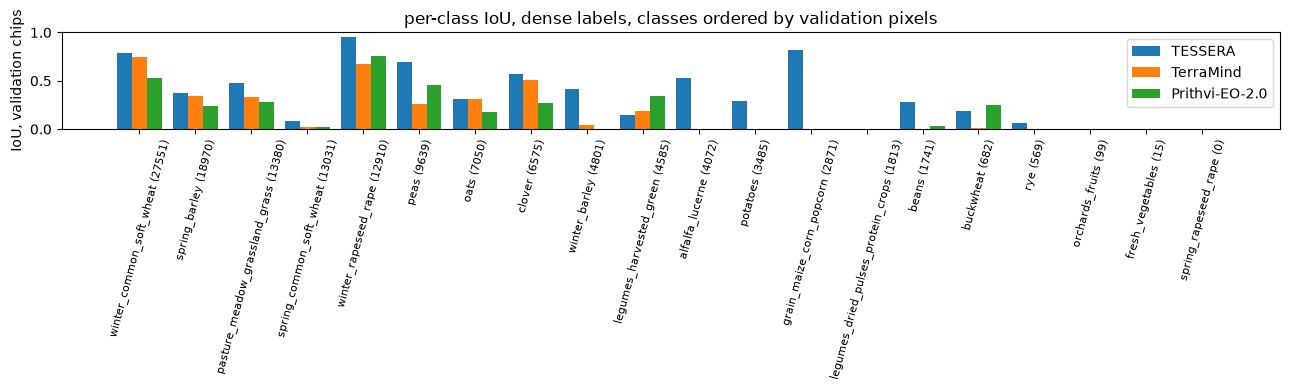

In [11]:
pv = preds[masks >= 0].numpy(); rv = masks[masks >= 0].numpy()
rows = []
for k, n in enumerate(NAMES):
    tp = np.sum((pv == k) & (rv == k)); fp = np.sum((pv == k) & (rv != k)); fn = np.sum((pv != k) & (rv == k))
    row = {"class": n, "val pixels": int((rv == k).sum()), "TESSERA IoU": tp / max(tp + fp + fn, 1)}
    for name, run in OTHERS.items():
        f = run / "P100_draw0_seed0/results.json"
        if f.exists(): row[f"{name.split()[0]} IoU"] = json.loads(f.read_text())["test_metrics"].get(f"test/IoU_{n}", np.nan)
    rows.append(row)
per_class = pd.DataFrame(rows).sort_values("val pixels", ascending=False)
cols = [c for c in per_class if c.endswith("IoU")]
xpos = np.arange(len(per_class)); w = 0.8 / len(cols)
fig, ax = plt.subplots(figsize=(13, 4))
for j, c in enumerate(cols):
    ax.bar(xpos + (j - (len(cols) - 1) / 2) * w, per_class[c], w, label=c.replace(" IoU", ""))
ax.set_xticks(xpos, [f"{c} ({v})" for c, v in zip(per_class["class"], per_class["val pixels"])], rotation=75, fontsize=8)
ax.set_ylabel("IoU, validation chips"); ax.legend(); ax.set_title("per-class IoU, dense labels, classes ordered by validation pixels")
plt.tight_layout()
per_class.round(3)

## 7. How to read the gap, and what comes next

On these chips TESSERA with a 0.2 M parameter MLP roughly **doubles** the macro F1 of both token-grid models, densely and at PCT = 5. It is tempting to read that as "the embedding is better". Several things differ at once, and the pilot cannot separate them:

1. **Input data.** TESSERA saw every clear Sentinel-1 and Sentinel-2 observation of 2021, radar included. TerraMind and Prithvi saw our 12 monthly S2 composites, several of them gap-filled winter months. Radar sees through the Baltic cloud cover.
2. **Resolution.** A 10 m raster against 160 m tokens. Parcel edges come free for TESSERA and must be invented by the token-grid decoders. This is the declared resolution-group factor.
3. **Head and optimisation.** A 0.2 M MLP at lr 1e-3 against 53 to 149 M decoders at lr 1e-4, on 8 chips. The token-grid models are capacity-heavy and still improving at epoch 40.
4. **Sample.** 4 validation chips, one seed, no spatial blocking.

The defensible claims are that the pipeline carries precomputed embeddings end to end, and that the **pixel_raster group looks strong under label scarcity** (0.31 macro F1 at PCT = 5). Whether the encoder deserves the credit is a question for the controlled comparisons.

**Next steps:**
- **A spatial head for `pixel_raster`**, a light UNet of about 1 to 2 M parameters, as the group's second head. The MLP-to-UNet gap shows what context adds at each K.
- **AlphaEarth** in the same slot: 64 dimensions, the same export pattern from Earth Engine, the same head. That is the head-to-head comparison CLAUDE.md asks for within this group.
- **TESSERA's own encoder** (weights released under CC0) on our pixel series. That would make the input data comparable with the TerraTorch models, and it would allow date and band attributions for Phase 2, which the precomputed product cannot give.
- **Parcel-level voting** as a post-processing baseline for the per-pixel speckle.